Bertrand demand: q_i = 1000 - 5*p_i + 2*p_j
Cournot inverse demand: P = 333.33 - 0.3333*Q
Marginal Cost (mc): 200
── Bertrand Nash Equilibrium ──
  Price:    P1 = 250.00, P2 = 250.00
  Quantity: q1 = 250.00, q2 = 250.00, Q = 500.00
  Profit:   π1 = 12500.00, π2 = 12500.00
── Cournot Nash Equilibrium ──
  Price:    P = 244.44
  Quantity: q1 = 133.33, q2 = 133.33, Q = 266.67
  Profit:   π1 = 5925.93, π2 = 5925.93
──────────────────────────────────────────
Metric                        Bertrand      Cournot
──────────────────────────────────────────
Price                           250.00       244.44
Total Quantity                  500.00       266.67
Consumer Surplus              20833.33     11851.85
Producer Surplus              25000.00     11851.85
Total Welfare                 45833.33     23703.70
──────────────────────────────────────────


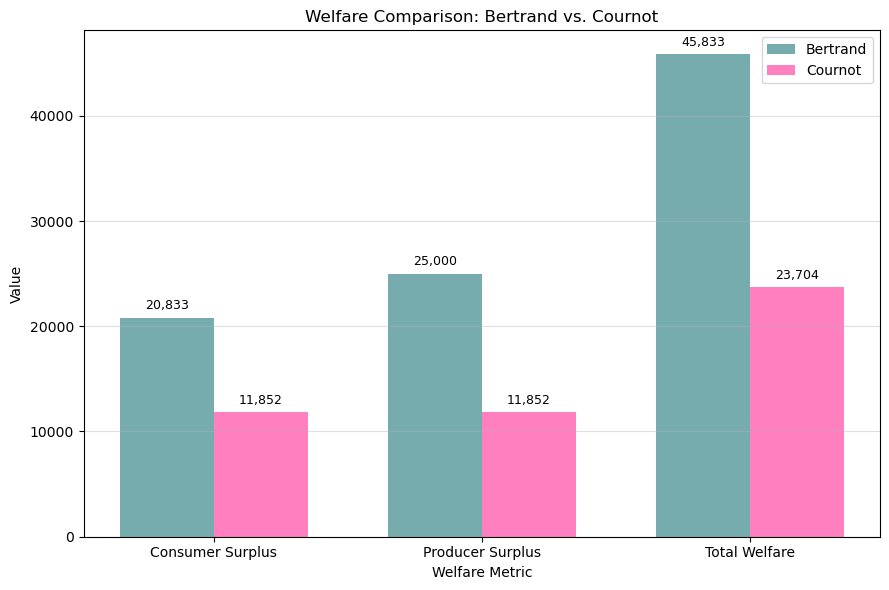


  Bertrand CS is 75.8% higher → consumers prefer Bertrand
  Cournot PS is  -52.6% higher → firms prefer Cournot
  Total Welfare: Bertrand = 45,833, Cournot = 23,704


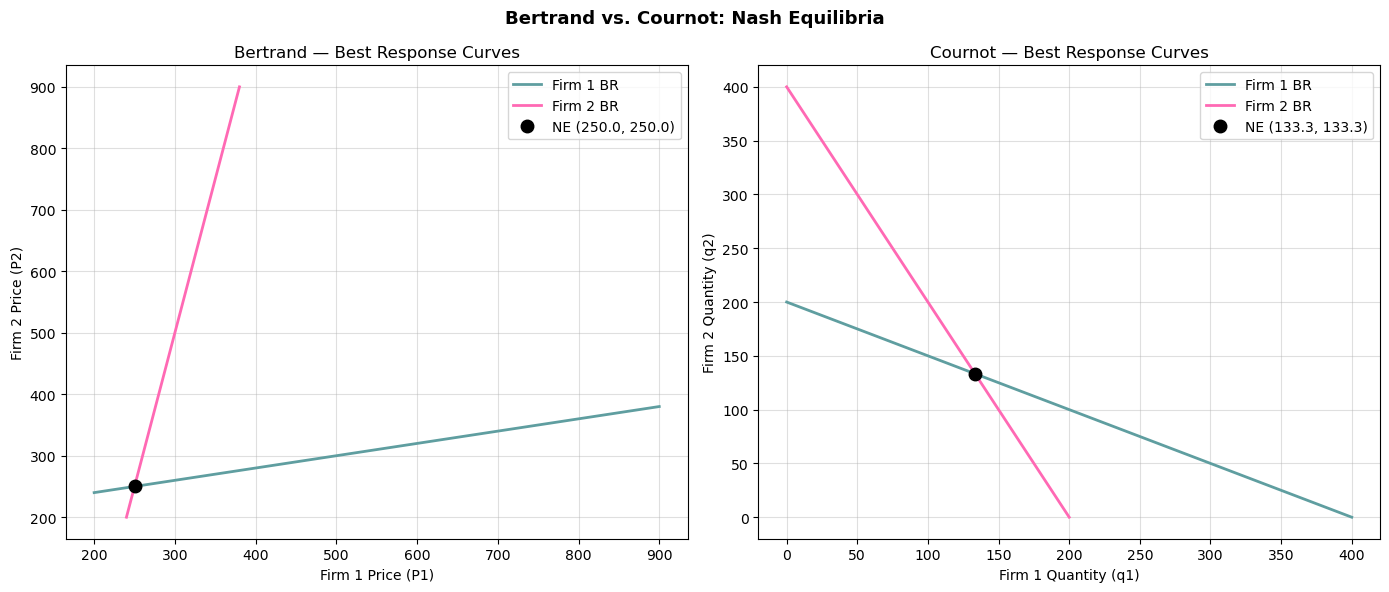

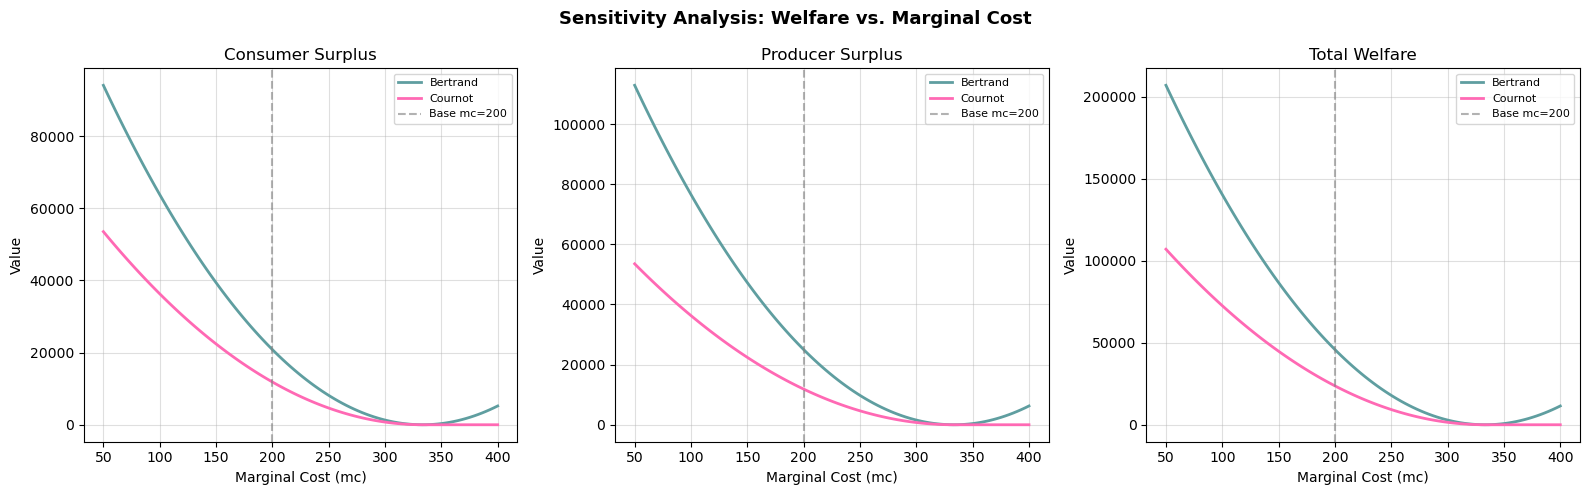

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# ── Parameters ──
a  = 1000   # base demand
b  = 5      # own-price sensitivity
c  = 2      # cross-price sensitivity
mc = 200    # marginal cost (same for both firms)

# Cournot uses linear inverse demand: P = A - B*Q
A = a / (b - c)
B = 1 / (b - c)

print(f"Bertrand demand: q_i = {a} - {b}*p_i + {c}*p_j")
print(f"Cournot inverse demand: P = {A:.2f} - {B:.4f}*Q")
print(f"Marginal Cost (mc): {mc}")

# ── Bertrand Equilibrium ──
def br1_B(p2): return (a + b*mc + c*p2) / (2*b)
def br2_B(p1): return (a + b*mc + c*p1) / (2*b)

def bertrand_system(p):
    p1, p2 = p
    return [p1 - br1_B(p2), p2 - br2_B(p1)]

p1_B, p2_B = fsolve(bertrand_system, [500, 500])

q1_B = a - b*p1_B + c*p2_B
q2_B = a - b*p2_B + c*p1_B
Q_B  = q1_B + q2_B

profit1_B = (p1_B - mc) * q1_B
profit2_B = (p2_B - mc) * q2_B

print("── Bertrand Nash Equilibrium ──")
print(f"  Price:    P1 = {p1_B:.2f}, P2 = {p2_B:.2f}")
print(f"  Quantity: q1 = {q1_B:.2f}, q2 = {q2_B:.2f}, Q = {Q_B:.2f}")
print(f"  Profit:   π1 = {profit1_B:.2f}, π2 = {profit2_B:.2f}")

# ── Cournot Equilibrium ──
def br1_C(q2): return max(0, (A - mc - B*q2) / (2*B))
def br2_C(q1): return max(0, (A - mc - B*q1) / (2*B))

def cournot_system(q):
    q1, q2 = q
    return [q1 - br1_C(q2), q2 - br2_C(q1)]

q_init = (A - mc) / (3 * B)   # analytical starting guess
q1_C, q2_C = fsolve(cournot_system, [q_init, q_init])
Q_C  = q1_C + q2_C
P_C  = A - B*Q_C

profit1_C = (P_C - mc) * q1_C
profit2_C = (P_C - mc) * q2_C

print("── Cournot Nash Equilibrium ──")
print(f"  Price:    P = {P_C:.2f}")
print(f"  Quantity: q1 = {q1_C:.2f}, q2 = {q2_C:.2f}, Q = {Q_C:.2f}")
print(f"  Profit:   π1 = {profit1_C:.2f}, π2 = {profit2_C:.2f}")

# ── Welfare Calculations ──
def compute_welfare(price, quantity):
    cs = 0.5 * (A - price) * quantity
    ps = (price - mc) * quantity
    tw = cs + ps
    return cs, ps, tw

CS_B, PS_B, TW_B = compute_welfare(p1_B, Q_B)
CS_C, PS_C, TW_C = compute_welfare(P_C,  Q_C)

print("──────────────────────────────────────────")
print(f"{'Metric':<25} {'Bertrand':>12} {'Cournot':>12}")
print("──────────────────────────────────────────")
print(f"{'Price':<25} {p1_B:>12.2f} {P_C:>12.2f}")
print(f"{'Total Quantity':<25} {Q_B:>12.2f} {Q_C:>12.2f}")
print(f"{'Consumer Surplus':<25} {CS_B:>12.2f} {CS_C:>12.2f}")
print(f"{'Producer Surplus':<25} {PS_B:>12.2f} {PS_C:>12.2f}")
print(f"{'Total Welfare':<25} {TW_B:>12.2f} {TW_C:>12.2f}")
print("──────────────────────────────────────────")

# ── Side-by-Side Welfare Bar Chart ──
labels    = ['Consumer Surplus', 'Producer Surplus', 'Total Welfare']
bert_vals = [CS_B, PS_B, TW_B]
cour_vals = [CS_C, PS_C, TW_C]

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, bert_vals, width, label='Bertrand', color='sandybrown', alpha=0.85)
bars2 = ax.bar(x + width/2, cour_vals, width, label='Cournot',  color='powderblue',   alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Welfare Metric')
ax.set_ylabel('Value')
ax.set_title('Welfare Comparison: Bertrand vs. Cournot')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"\n  Bertrand CS is {((CS_B - CS_C)/CS_C)*100:.1f}% higher → consumers prefer Bertrand")
print(f"  Cournot PS is  {((PS_C - PS_B)/PS_B)*100:.1f}% higher → firms prefer Cournot")
print(f"  Total Welfare: Bertrand = {TW_B:,.0f}, Cournot = {TW_C:,.0f}")

# ── Dual Best Response Curves ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bertrand (price space)
p_range = np.linspace(mc, 900, 200)
ax1.plot(p_range, br1_B(p_range), label='Firm 1 BR', color='cadetblue', linewidth=2)
ax1.plot(br2_B(p_range), p_range, label='Firm 2 BR', color='hotpink',   linewidth=2)
ax1.plot(p1_B, p2_B, 'ko', markersize=9, label=f'NE ({p1_B:.1f}, {p2_B:.1f})')
ax1.set_xlabel('Firm 1 Price (P1)')
ax1.set_ylabel('Firm 2 Price (P2)')
ax1.set_title('Bertrand — Best Response Curves')
ax1.legend()
ax1.grid(True, alpha=0.4)

# Cournot (quantity space)
q_range  = np.linspace(0, (A - mc)/B, 200)
br1_vals = np.array([br1_C(q) for q in q_range])
br2_vals = np.array([br2_C(q) for q in q_range])
ax2.plot(q_range, br1_vals, label='Firm 1 BR', color='cadetblue', linewidth=2)
ax2.plot(br2_vals, q_range, label='Firm 2 BR', color='hotpink',   linewidth=2)
ax2.plot(q1_C, q2_C, 'ko', markersize=9, label=f'NE ({q1_C:.1f}, {q2_C:.1f})')
ax2.set_xlabel('Firm 1 Quantity (q1)')
ax2.set_ylabel('Firm 2 Quantity (q2)')
ax2.set_title('Cournot — Best Response Curves')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.suptitle('Bertrand vs. Cournot: Nash Equilibria', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Sensitivity Analysis: Welfare vs. Marginal Cost ──
mc_range = np.linspace(50, 400, 100)

CS_B_list, PS_B_list, TW_B_list = [], [], []
CS_C_list, PS_C_list, TW_C_list = [], [], []

for mc_val in mc_range:
    # Bertrand
    def br1_B_mc(p2): return (a + b*mc_val + c*p2) / (2*b)
    def br2_B_mc(p1): return (a + b*mc_val + c*p1) / (2*b)
    def system_B(p):
        p1, p2 = p
        return [p1 - br1_B_mc(p2), p2 - br2_B_mc(p1)]
    p_init_val = (a + b*mc_val + c * ((a + b*mc_val) / (2*b - c))) / (2*b)
    p1_b, p2_b = fsolve(system_B, [p_init_val, p_init_val])
    q1_b = a - b*p1_b + c*p2_b
    q2_b = a - b*p2_b + c*p1_b
    Q_b  = q1_b + q2_b
    cs_b = 0.5 * (A - p1_b) * Q_b
    ps_b = (p1_b - mc_val) * Q_b
    CS_B_list.append(cs_b); PS_B_list.append(ps_b); TW_B_list.append(cs_b + ps_b)

    # Cournot
    def br1_C_mc(q2): return max(0, (A - mc_val - B*q2) / (2*B))
    def br2_C_mc(q1): return max(0, (A - mc_val - B*q1) / (2*B))
    def system_C(q):
        q1, q2 = q
        return [q1 - br1_C_mc(q2), q2 - br2_C_mc(q1)]
    q_init_val = (A - mc_val) / (3 * B)   # analytical starting guess per iteration
    q1_c, q2_c = fsolve(system_C, [q_init_val, q_init_val])
    Q_c  = q1_c + q2_c
    P_c  = A - B*Q_c
    cs_c = 0.5 * (A - P_c) * Q_c
    ps_c = (P_c - mc_val) * Q_c
    CS_C_list.append(cs_c); PS_C_list.append(ps_c); TW_C_list.append(cs_c + ps_c)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = [
    ('Consumer Surplus', CS_B_list, CS_C_list),
    ('Producer Surplus', PS_B_list, PS_C_list),
    ('Total Welfare',    TW_B_list, TW_C_list),
]
for ax, (title, bv, cv) in zip(axes, metrics):
    ax.plot(mc_range, bv, label='Bertrand', color='cadetblue', linewidth=2)
    ax.plot(mc_range, cv, label='Cournot',  color='hotpink',   linewidth=2)
    ax.axvline(x=mc, color='gray', linestyle='--', alpha=0.6, label=f'Base mc={mc}')
    ax.set_xlabel('Marginal Cost (mc)')
    ax.set_ylabel('Value')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle('Sensitivity Analysis: Welfare vs. Marginal Cost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()